In [1]:
import sys
from matplotlib import pyplot as plt
from sklift.metrics import uplift_at_k
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
from sklift.models import ClassTransformation
from catboost import CatBoostClassifier
from sklift.metrics import qini_auc_score

# install uplift library scikit-uplift and other libraries
#!{sys.executable} -m pip install scikit-uplift dill catboost

# %config InlineBackend.figure_format = 'svg'
# %matplotlib inline

## Overview:
Load the model, predict uplift scores on 2 models and decide treatment. Evaluate their performance also.

In [2]:
mens_model_path = 'models/mens_uplift_model.pkl'
womens_model_path = 'models/womens_uplift_model.pkl'

mens_model=joblib.load(mens_model_path)
womens_model=joblib.load(womens_model_path)

mens_features = mens_model.estimator.feature_names_
womens_features = womens_model.estimator.feature_names_


In [3]:
df_input=pd.read_parquet('data/hillstrom.parquet')

In [4]:
mens_model.estimator.feature_names_

['recency',
 'history_segment',
 'history',
 'mens',
 'womens',
 'zip_code',
 'newbie',
 'channel']

In [5]:
# 2. Select and reorder df_input for each model
# .reindex() is safer than .drop() because it automatically reorders 
# the columns to match your list AND drops unused columns.
df_mens_input = df_input.reindex(columns=mens_features)
df_womens_input = df_input.reindex(columns=womens_features)

# 3. Predict uplift scores
# Now you are 100% sure the column order matches what the model saw during training
df_input['mens_uplift'] = mens_model.predict(df_mens_input)
df_input['womens_uplift'] = womens_model.predict(df_womens_input)


## Qini curve and Qini AUC for mens model

In [ ]:
df_mens=df_input[df_input['treatment']!='Womens E-Mail']
df_mens['treatment']=np.where(df_mens['treatment']=='Mens E-Mail',1,0)

In [27]:
df_womens=df_input[df_input['treatment']!='Mens E-Mail']
df_womens['treatment']=np.where(df_womens['treatment']=='Womens E-Mail',1,0)

C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_32848\1440073084.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_womens['treatment']=np.where(df_womens['treatment']=='Womens E-Mail',1,0)


In [28]:
df_womens['treatment'].value_counts()

treatment
1    21387
0    21306
Name: count, dtype: int64

In [25]:
df_mens['treatment'].value_counts()

treatment
1    21307
0    21306
Name: count, dtype: int64

The AUUC on the test dataset is 0.04191187509187343


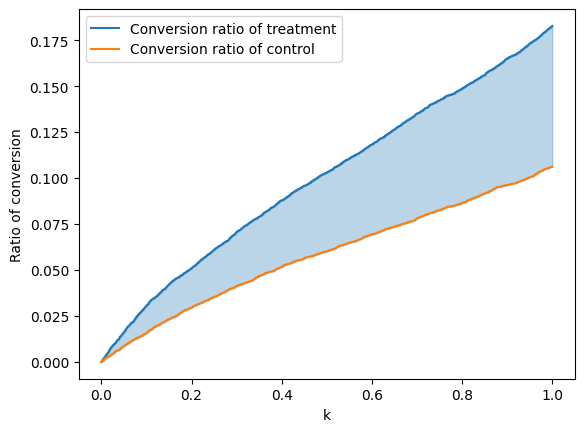

In [26]:
# Predictions
predictions = df_mens['mens_uplift'].values

# Outcomes and treatments
outcomes = df_mens['visit'].values
treatment = df_mens['treatment'].values
control = 1 - treatment

# Counts
num_treatments = np.sum(treatment)
num_control = np.sum(control)
num_examples = len(predictions)

# Sort by predicted uplift (descending)
prediction_order = predictions.argsort()[::-1]
outcomes_sorted = outcomes[prediction_order]
treatment_sorted = treatment[prediction_order]
control_sorted = control[prediction_order]

# Cumulative conversion ratios
ratio_treatment = np.cumsum(outcomes_sorted * treatment_sorted) / num_treatments
ratio_control = np.cumsum(outcomes_sorted * control_sorted) / num_control

# X-axis (normalized population)
x = np.linspace(0, 1, num_examples)

# Plot
fig, ax = plt.subplots()
ax.plot(x, ratio_treatment, label='Conversion ratio of treatment')
ax.plot(x, ratio_control, label='Conversion ratio of control')

# Fill between curves
ax.fill_between(x, ratio_treatment, ratio_control,
                where=(ratio_treatment > ratio_control),
                color='C0', alpha=0.3)
ax.fill_between(x, ratio_treatment, ratio_control,
                where=(ratio_treatment < ratio_control),
                color='C1', alpha=0.3)

ax.set_xlabel('k')
ax.set_ylabel('Ratio of conversion')
ax.legend()

# AUUC calculation
auuc = np.trapezoid(ratio_treatment - ratio_control, dx=1/num_examples)
print(f'The AUUC on the test dataset is {auuc}')

plt.show()

The AUUC on the test dataset is 0.021725459019004172


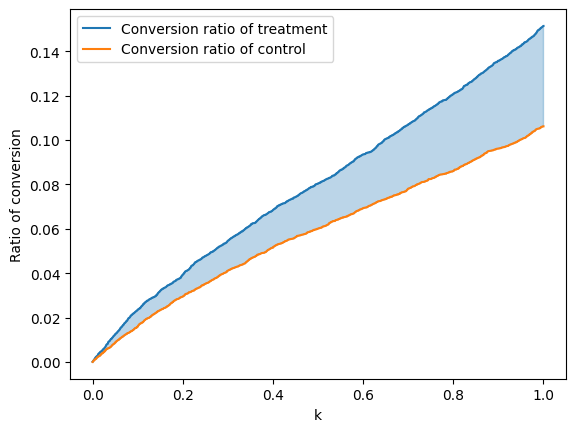

In [29]:
# Predictions
predictions = df_womens['mens_uplift'].values

# Outcomes and treatments
outcomes = df_womens['visit'].values
treatment = df_womens['treatment'].values
control = 1 - treatment

# Counts
num_treatments = np.sum(treatment)
num_control = np.sum(control)
num_examples = len(predictions)

# Sort by predicted uplift (descending)
prediction_order = predictions.argsort()[::-1]
outcomes_sorted = outcomes[prediction_order]
treatment_sorted = treatment[prediction_order]
control_sorted = control[prediction_order]

# Cumulative conversion ratios
ratio_treatment = np.cumsum(outcomes_sorted * treatment_sorted) / num_treatments
ratio_control = np.cumsum(outcomes_sorted * control_sorted) / num_control

# X-axis (normalized population)
x = np.linspace(0, 1, num_examples)

# Plot
fig, ax = plt.subplots()
ax.plot(x, ratio_treatment, label='Conversion ratio of treatment')
ax.plot(x, ratio_control, label='Conversion ratio of control')

# Fill between curves
ax.fill_between(x, ratio_treatment, ratio_control,
                where=(ratio_treatment > ratio_control),
                color='C0', alpha=0.3)
ax.fill_between(x, ratio_treatment, ratio_control,
                where=(ratio_treatment < ratio_control),
                color='C1', alpha=0.3)

ax.set_xlabel('k')
ax.set_ylabel('Ratio of conversion')
ax.legend()

# AUUC calculation
auuc = np.trapezoid(ratio_treatment - ratio_control, dx=1/num_examples)
print(f'The AUUC on the test dataset is {auuc}')

plt.show()

## Calibration - Makes 2 models comparable on the same scale

In [30]:
import pandas as pd
import numpy as np
from sklearn.isotonic import IsotonicRegression

def train_uplift_translator(df_val, raw_score_col, treatment_col, target_col):
    """
    df_val: A validation dataset (or your training data if you don't have one)
    raw_score_col: The string name of the column containing the model's prediction
    """
    df = df_val.copy()
    
    # 1. Chop the raw predictions into 15 equal-sized buckets (quantiles)
    df['bucket'] = pd.qcut(df[raw_score_col], q=15, duplicates='drop')
    
    bucket_stats = []
    
    # 2. For each bucket, calculate the ACTUAL real-world uplift
    for bucket_name, group in df.groupby('bucket', observed=True):
        
        # Actual conversion of treated users in this bucket
        treat_conv = group[group[treatment_col] == 1][target_col].mean()
        # Actual conversion of control users in this bucket
        ctrl_conv = group[group[treatment_col] == 0][target_col].mean()
        
        # Safe fallback if a bucket is empty
        treat_conv = 0 if pd.isna(treat_conv) else treat_conv
        ctrl_conv = 0 if pd.isna(ctrl_conv) else ctrl_conv
        
        actual_uplift = treat_conv - ctrl_conv
        avg_raw_score = group[raw_score_col].mean()
        
        bucket_stats.append({
            'avg_raw_score': avg_raw_score,
            'actual_uplift': actual_uplift
        })
        
    stats_df = pd.DataFrame(bucket_stats)
    
    # 3. Train a machine learning Translator (Isotonic Regression)
    # This learns the rule: "When the model says X, the reality is Y"
    translator = IsotonicRegression(out_of_bounds='clip')
    translator.fit(stats_df['avg_raw_score'], stats_df['actual_uplift'])
    
    return translator

In [31]:
df_input['mens_treatment']=np.where(df_input['treatment']=='Mens E-Mail',1,0  )
df_input['womens_treatment']=np.where(df_input['treatment']=='Womens E-Mail',1,0  )

In [33]:
# Assuming you already trained ct_model_A and ct_model_B

# 1. Get raw scores on your historical data
df_input['mens_uplift'] = mens_model.predict(df_mens_input)
df_input['womens_uplift'] = womens_model.predict(df_womens_input)

# 2. Train the Translators
translator_A = train_uplift_translator(df_input, 'mens_uplift', 'mens_treatment', 'visit')
translator_B = train_uplift_translator(df_input, 'womens_uplift', 'womens_treatment', 'visit')

In [34]:
df_input['treatment']

0        Womens E-Mail
1            No E-Mail
2        Womens E-Mail
3          Mens E-Mail
4        Womens E-Mail
             ...      
63995      Mens E-Mail
63996      Mens E-Mail
63997      Mens E-Mail
63998    Womens E-Mail
63999      Mens E-Mail
Name: treatment, Length: 64000, dtype: object

In [35]:
df_mens_input

,recency,history_segment,history,mens,womens,zip_code,newbie,channel
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web
...,...,...,...,...,...,...,...,...
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel


In [36]:
# 2. Translate those scores into TRUE INCREMENTAL CONVERSION
df_input['mens_calibrated_uplift'] = translator_A.predict(df_input['mens_uplift'])
df_input['womens_calibrated_uplift'] = translator_B.predict(df_input['womens_uplift'])

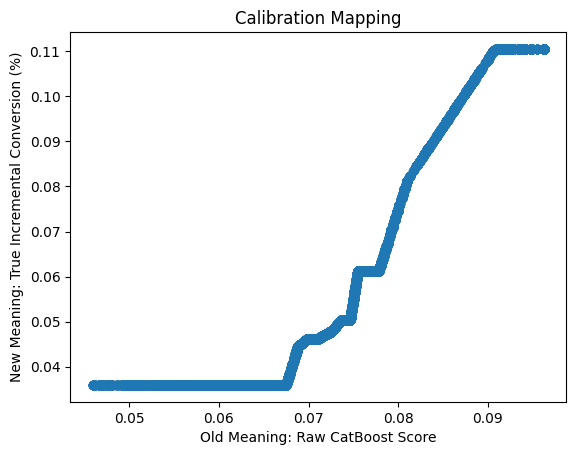

In [37]:
import matplotlib.pyplot as plt

plt.scatter(df_input['mens_uplift'], df_input['mens_calibrated_uplift'], alpha=0.5)
plt.xlabel('Old Meaning: Raw CatBoost Score')
plt.ylabel('New Meaning: True Incremental Conversion (%)')
plt.title('Calibration Mapping')
plt.show()

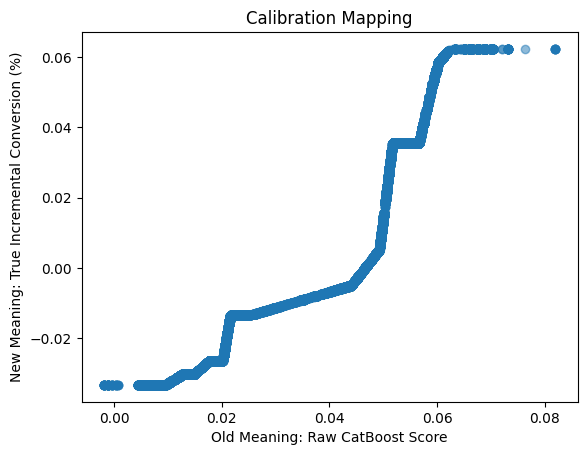

In [38]:
import matplotlib.pyplot as plt

plt.scatter(df_input['womens_uplift'], df_input['womens_calibrated_uplift'], alpha=0.5)
plt.xlabel('Old Meaning: Raw CatBoost Score')
plt.ylabel('New Meaning: True Incremental Conversion (%)')
plt.title('Calibration Mapping')
plt.show()

## Conclusion: Model use
- We should use the calibrated uplift scores to prioritize users for treatment, not the raw model scores.
- It should have a minimum threshold, if below that none action were taken.    
- Then we compare between mens vs womens calibrated score, which higher score should be prioritized for treatment.    